<a href="https://colab.research.google.com/github/maisasq123/lia1_2026_2/blob/main/Entregas%20-%20Ma%C3%ADsa%20Queiroz/YOLO26_Segmentacao_COCO8_Seg/YOLO26_Segmentacao_COCO8_Seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicação de Segmentação de Objetos utilizando YOLO26

A Visão Computacional é uma área da Inteligência Artificial que permite que computadores analisem e interpretem imagens e vídeos.

Neste trabalho será utilizada a biblioteca Ultralytics e o modelo YOLO26 para realizar a segmentação de objetos em imagens.

Diferentemente da detecção de objetos, que identifica os objetos por meio de caixas delimitadoras, a segmentação permite identificar a região correspondente a cada objeto na imagem.

## Objetivo

O objetivo deste trabalho é aplicar o modelo YOLO26 em uma imagem do dataset COCO8-Seg, disponibilizado pela Ultralytics, para realizar a segmentação dos objetos presentes na imagem.

### Instalar o Ultralytics

In [ ]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.6 MB/s eta 0:00:00


### Importar o YOLO

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


### Carregar Modelo de Segmentação

In [ ]:
model = YOLO("yolo26n-seg.pt")

## Dataset COCO8-Seg

O COCO8-Seg é um pequeno dataset disponibilizado pela Ultralytics para tarefas de segmentação de objetos.

Neste trabalho, será utilizada uma imagem do dataset para aplicar o modelo YOLO26 e visualizar os objetos segmentados.

### Baixar o dataset COCO8-Seg

In [ ]:
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8-seg.zip

### Descompactar o Dataset

In [ ]:
!unzip -q coco8-seg.zip

### Visualizar as Imagens Disponíveis

In [ ]:
!find /content/coco8-seg/images -type f

/content/coco8-seg/images/val/000000000042.jpg
/content/coco8-seg/images/val/000000000061.jpg
/content/coco8-seg/images/val/000000000049.jpg
/content/coco8-seg/images/val/000000000036.jpg
/content/coco8-seg/images/train/000000000030.jpg
/content/coco8-seg/images/train/000000000009.jpg
/content/coco8-seg/images/train/000000000025.jpg
/content/coco8-seg/images/train/000000000034.jpg


## Seleção da Imagem

Será utilizada uma imagem do conjunto de validação do COCO8-Seg para realizar a segmentação dos objetos presentes na cena.

In [ ]:
# Selecionar uma imagem do conjunto de validação

imagem = "/content/coco8-seg/images/val/000000000036.jpg"

print(imagem)

/content/coco8-seg/images/val/000000000036.jpg


### Visualizar Imagem antes da Segmentação

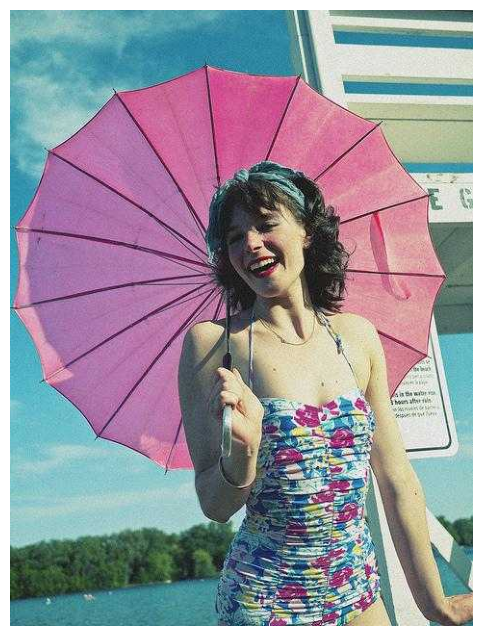

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(imagem)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

## Segmentação da Imagem

Nesta etapa, o modelo YOLO26 será utilizado para identificar e segmentar os objetos presentes na imagem selecionada.

In [ ]:
results = model.predict(
    source=imagem,
    conf=0.2
)


image 1/1 /content/coco8-seg/images/val/000000000036.jpg: 640x512 1 person, 1 umbrella, 649.8ms
Speed: 21.9ms preprocess, 649.8ms inference, 17.3ms postprocess per image at shape (1, 3, 640, 512)


### Exibir a imagem segmentada

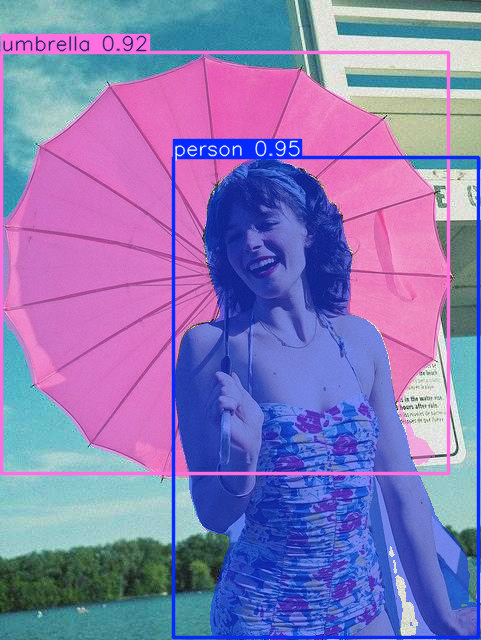

In [ ]:
results[0].show()

### Exibir os Objetos Identificados e Suas Confianças

In [ ]:
for box in results[0].boxes:
    classe = int(box.cls[0])
    confianca = float(box.conf[0])

    print(f"{model.names[classe]}: {confianca:.2%}")

person: 95.06%
umbrella: 91.94%


## Teste com uma Imagem Externa

Para testar a aplicação em uma situação diferente, será utilizada uma imagem escolhida pelo usuário.

A imagem será carregada no Google Colab e analisada pelo modelo YOLO26 para verificar quais objetos podem ser identificados e segmentados.

### Fazer upload de uma imagem

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Captura de tela 2026-09-01 191911.png to Captura de tela 2026-09-01 191911.png


### Obter o nome da imagem enviada

In [ ]:
imagem_teste = list(uploaded.keys())[0]

print(f"Imagem selecionada: {imagem_teste}")

Imagem selecionada: Captura de tela 2026-09-01 191911.png


### Exibir a Imagem antes da Segmentação


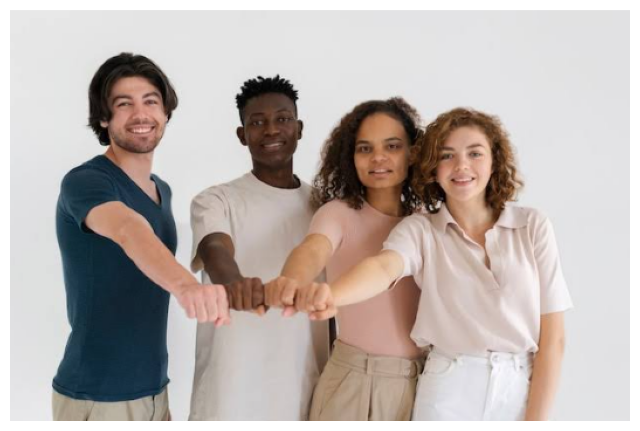

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_teste = Image.open(imagem_teste)

plt.figure(figsize=(8, 8))
plt.imshow(img_teste)
plt.axis("off")
plt.show()

### Realizar a Segmentação

In [ ]:
results_teste = model.predict(
    source=imagem_teste,
    conf=0.2
)


image 1/1 /content/Captura de tela 2026-09-01 191911.png: 448x640 5 persons, 294.4ms
Speed: 34.4ms preprocess, 294.4ms inference, 9.7ms postprocess per image at shape (1, 3, 448, 640)


### Exibir a Imagem Segmentada

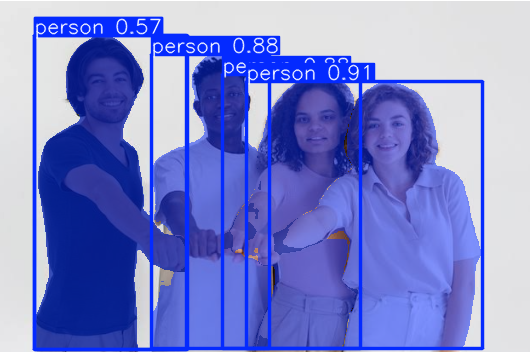

In [ ]:
results_teste[0].show()

### Exibir os objetos identificados

In [ ]:
for box in results_teste[0].boxes:
    classe = int(box.cls[0])
    confianca = float(box.conf[0])

    print(f"{model.names[classe]}: {confianca:.2%}")

person: 90.97%
person: 88.45%
person: 87.98%
person: 56.68%
person: 36.33%
